# Skin Lesion Classification — Dual Branch ResNet50

Full pipeline: EDA → Model → Training → Evaluation  
Dataset: **Derm7pt** (paired clinical + dermoscopic images)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DERM7PT_DIR = Path('dataset') / 'Derm7pt'

## Load & Clean Data

In [15]:
# Load Derm7pt
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
print(f"Shape: {derm_df.shape}")

# Build image paths
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path'] = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis'] = derm_df['diagnosis'].str.strip().str.lower()

# Verify images exist
clinic_ok = derm_df['clinic_path'].apply(lambda x: Path(x).exists()).sum()
derm_ok = derm_df['derm_path'].apply(lambda x: Path(x).exists()).sum()
print(f"Clinical images: {clinic_ok}/{len(derm_df)}")
print(f"Dermoscopic images: {derm_ok}/{len(derm_df)}")

Shape: (1011, 19)
Clinical images: 1011/1011
Dermoscopic images: 1011/1011


## Visualizations

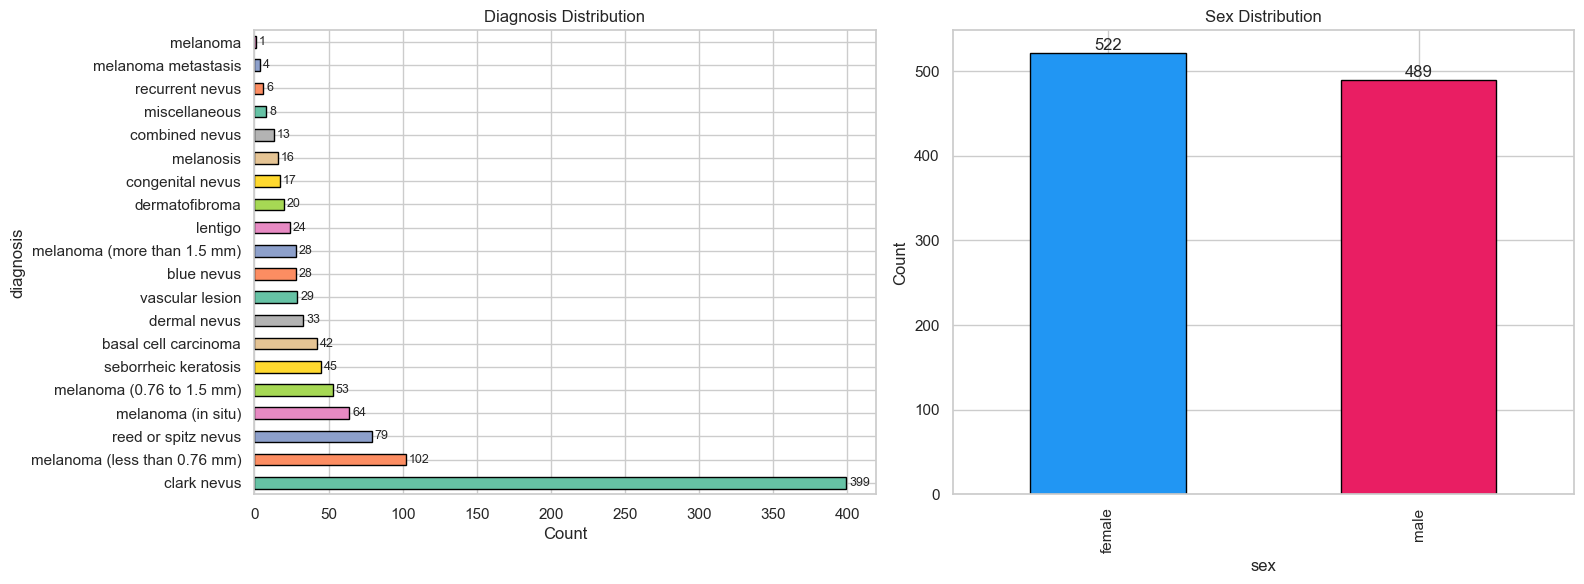

In [16]:
# Diagnosis distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

counts = derm_df['diagnosis'].value_counts()
counts.plot(kind='barh', color=sns.color_palette('Set2', len(counts)), edgecolor='black', ax=ax1)
ax1.set_title('Diagnosis Distribution')
ax1.set_xlabel('Count')
for i, (val, c) in enumerate(counts.items()):
    ax1.text(c + 2, i, str(c), va='center', fontsize=9)

derm_df['sex'].value_counts().plot(kind='bar', color=['#2196F3', '#E91E63'], edgecolor='black', ax=ax2)
ax2.set_title('Sex Distribution')
ax2.set_ylabel('Count')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

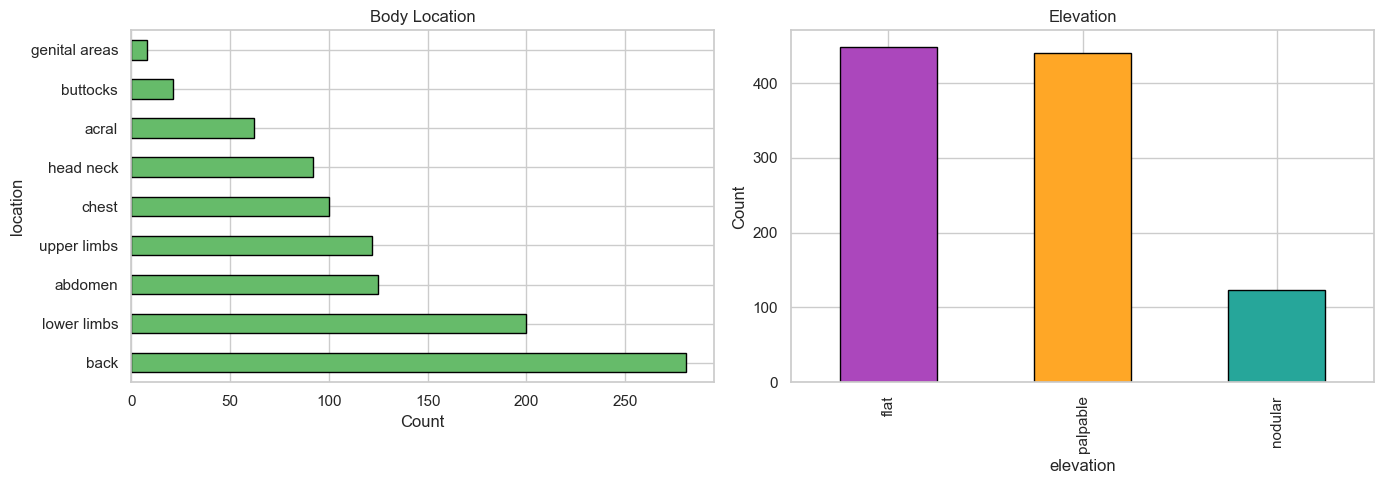

In [17]:
# Location + elevation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

derm_df['location'].value_counts().plot(kind='barh', color='#66BB6A', edgecolor='black', ax=ax1)
ax1.set_title('Body Location')
ax1.set_xlabel('Count')

derm_df['elevation'].value_counts().plot(kind='bar', color=['#AB47BC', '#FFA726', '#26A69A'], edgecolor='black', ax=ax2)
ax2.set_title('Elevation')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

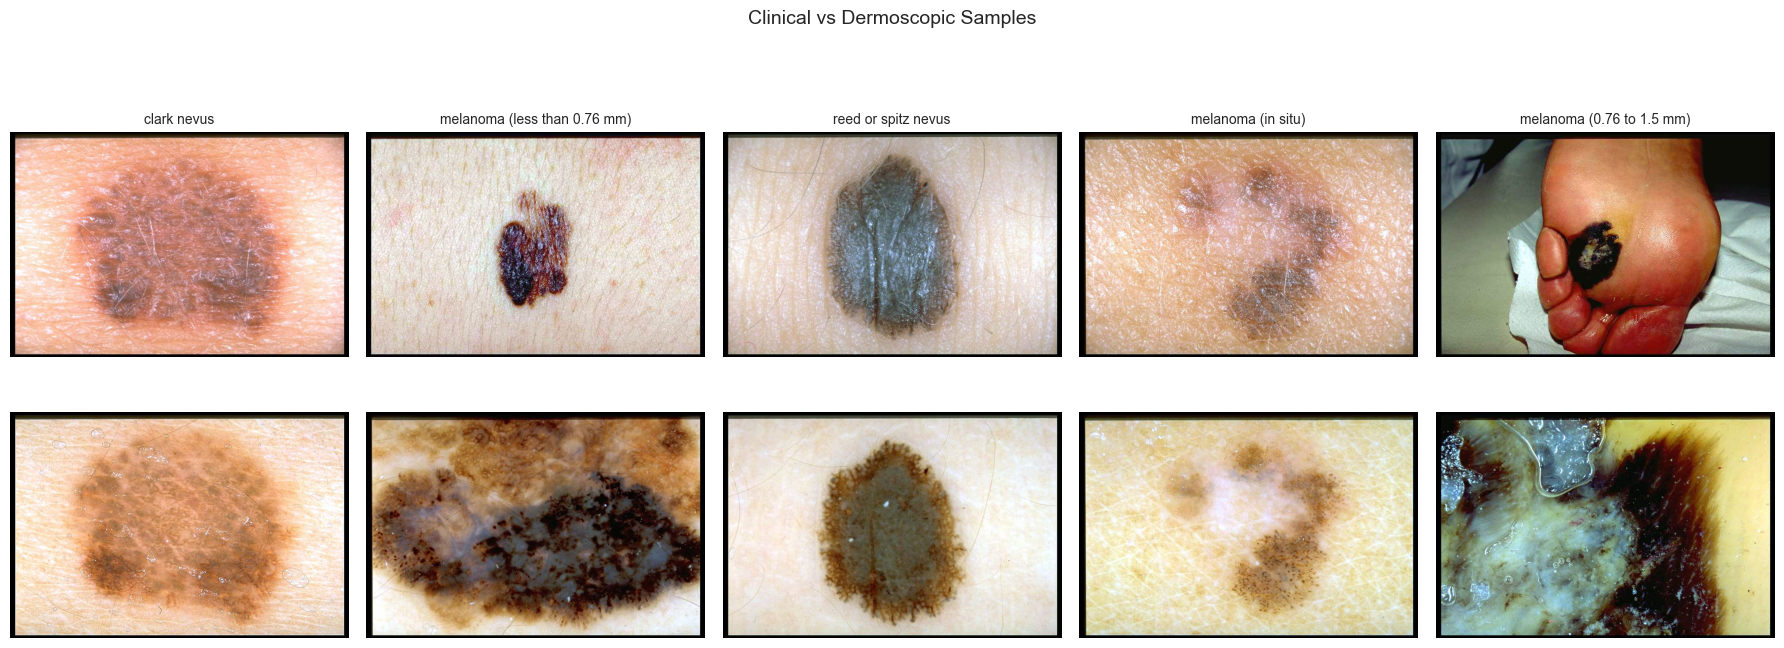

In [18]:
# Sample images — clinical + dermoscopic pairs for top 5 diagnoses
top5 = derm_df['diagnosis'].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for j, cls in enumerate(top5):
    sample = derm_df[derm_df['diagnosis'] == cls].iloc[0]
    axes[0, j].imshow(Image.open(sample['clinic_path']))
    axes[0, j].set_title(cls, fontsize=10)
    axes[0, j].axis('off')
    axes[1, j].imshow(Image.open(sample['derm_path']))
    axes[1, j].axis('off')
axes[0, 0].set_ylabel('Clinical', fontsize=12)
axes[1, 0].set_ylabel('Dermoscopic', fontsize=12)
plt.suptitle('Clinical vs Dermoscopic Samples', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Prepare Labels

Group 20 Derm7pt diagnoses into 5 standard diagnostic classes: MEL, NV, BCC, SK, MISC.

Samples: 1011, Classes: ['BCC', 'MEL', 'MISC', 'NV', 'SK']
diagnosis_group
NV      575
MEL     252
MISC     97
SK       45
BCC      42
Name: count, dtype: int64


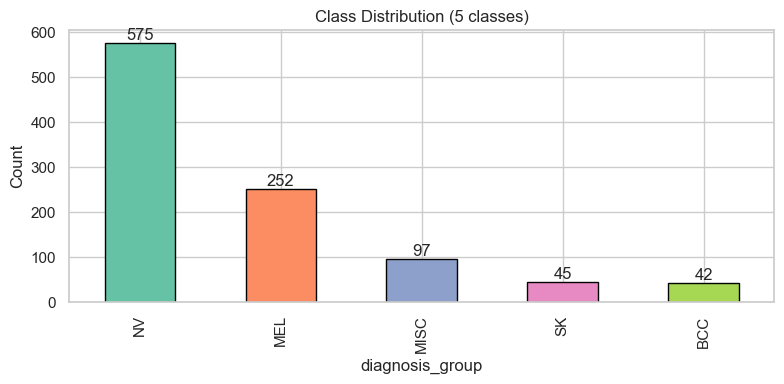

In [19]:
# Group 20 diagnoses into 5 standard classes
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL', 'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV', 'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

df = derm_df.copy()
class_names = sorted(df['diagnosis_group'].unique())
label_map = {name: i for i, name in enumerate(class_names)}
df['label'] = df['diagnosis_group'].map(label_map)

print(f"Samples: {len(df)}, Classes: {class_names}")
print(df['diagnosis_group'].value_counts())

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['diagnosis_group'].value_counts()
counts.plot(kind='bar', color=sns.color_palette('Set2', len(counts)), edgecolor='black', ax=ax)
ax.set_title('Class Distribution (5 classes)')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Load MILK10k Dataset

MILK10k: 5,240 lesions, each with paired clinical close-up + dermoscopic image.  
Classes mapped to Derm7pt's 5-class scheme. Dropped: AKIEC, SCCKA, INF, BEN_OTH, MAL_OTH (no Derm7pt equivalent).

In [20]:
MILK_DIR = Path('dataset') / 'milk10k'

milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')

# Map MILK10k 11 classes → Derm7pt 5 classes
milk_class_map = {
    'MEL':  'MEL',
    'NV':   'NV',
    'BCC':  'BCC',
    'BKL':  'SK',    # benign keratosis-like (includes SK, lentigo)
    'DF':   'MISC',  # dermatofibroma
    'VASC': 'MISC',  # vascular lesion
}
drop_classes = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}

# Assign label per lesion via idxmax on one-hot ground truth
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)

# Build clinic + derm paths from metadata image_type column
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')

milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

clinic_ok = milk_df['clinic_path'].apply(lambda x: Path(x).exists()).sum()
derm_ok   = milk_df['derm_path'].apply(lambda x: Path(x).exists()).sum()
print(f"MILK10k: {len(milk_df)} lesions after filtering")
print(f"Clinical images found:    {clinic_ok}/{len(milk_df)}")
print(f"Dermoscopic images found: {derm_ok}/{len(milk_df)}")
print(milk_df['diagnosis_group'].value_counts())

MILK10k: 4361 lesions after filtering
Clinical images found:    4361/4361
Dermoscopic images found: 4361/4361
diagnosis_group
BCC     2522
NV       746
SK       544
MEL      450
MISC      99
Name: count, dtype: int64


Combined dataset: 5372 samples, 5 classes
Classes: ['BCC', 'MEL', 'MISC', 'NV', 'SK']

diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196
Name: count, dtype: int64

source
MILK10k    4361
Derm7pt    1011
Name: count, dtype: int64


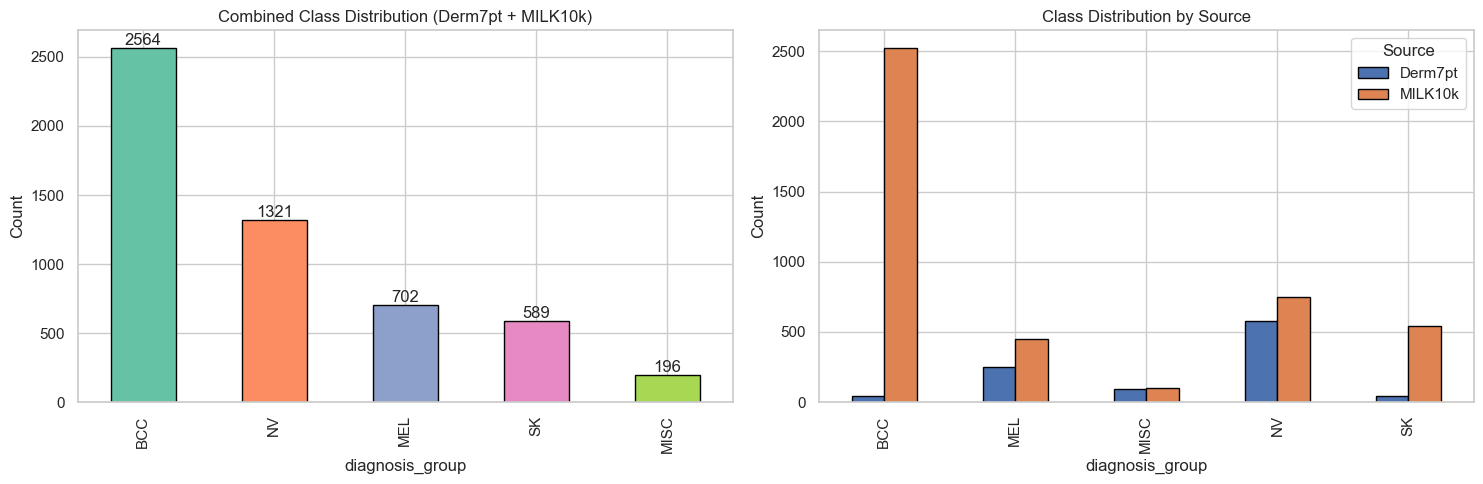

In [21]:
# Merge Derm7pt + MILK10k into combined df
derm_df_clean = df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm_df_clean['source'] = 'Derm7pt'

combined = pd.concat(
    [derm_df_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True
)

# Re-assign integer labels (same order as before: BCC=0, MEL=1, MISC=2, NV=3, SK=4)
class_names = sorted(combined['diagnosis_group'].unique())
label_map   = {name: i for i, name in enumerate(class_names)}
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined  # downstream cells use df unchanged

print(f"Combined dataset: {len(df)} samples, {len(class_names)} classes")
print(f"Classes: {class_names}")
print()
print(df['diagnosis_group'].value_counts())
print()
print(df['source'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df['diagnosis_group'].value_counts()
counts.plot(kind='bar', color=sns.color_palette('Set2', len(counts)), edgecolor='black', ax=axes[0])
axes[0].set_title('Combined Class Distribution (Derm7pt + MILK10k)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom')

df.groupby(['source', 'diagnosis_group']).size().unstack(fill_value=0).T.plot(
    kind='bar', ax=axes[1], edgecolor='black', color=['#4C72B0', '#DD8452'])
axes[1].set_title('Class Distribution by Source')
axes[1].set_ylabel('Count')
axes[1].legend(title='Source')
plt.tight_layout()
plt.show()

## EDA Summary

**Derm7pt**: 1,011 cases — paired clinical + dermoscopic images, 20 diagnoses → 5 classes  
**MILK10k**: 5,240 cases — paired clinical close-up + dermoscopic images, 11 classes → 5 mapped (6 dropped)

Combined: ~6,000+ paired lesions across 5 classes: **NV**, **MEL**, **BCC**, **SK**, **MISC**

Class imbalance handled via WeightedRandomSampler + weighted CrossEntropyLoss.

## Model — Dual Branch ResNet50

Two ResNet50s process two different images of the same lesion:
- **Branch A**: Clinical photo (regular camera) → ResNet50
- **Branch B**: Dermoscopic photo (skin microscope) → ResNet50
- Concatenate features (4096×7×7) → 1×1 Conv (1024) → Classifier

Dataset: Derm7pt + MILK10k combined, ~6,000+ paired samples, 5 classes.

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import copy, time

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [23]:
# Dataset class
class SkinLesionDualDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

# Stratified split (70/15/15)
labels = df['label'].values
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=42)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
val_ds = SkinLesionDualDataset(df.iloc[val_idx], val_transform)
test_ds = SkinLesionDualDataset(df.iloc[test_idx], val_transform)

# Weighted sampler for class imbalance
train_labels = labels[train_idx]
class_counts = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_labels), replacement=True)

# Loss weights
loss_weights = torch.tensor([len(train_labels) / (len(class_names) * c) for c in class_counts], dtype=torch.float32).to(device)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Class weights: {dict(zip(class_names, loss_weights.cpu().numpy().round(2)))}")

Train: 3760 | Val: 806 | Test: 806
Class weights: {'BCC': 0.42, 'MEL': 1.53, 'MISC': 5.49, 'NV': 0.81, 'SK': 1.83}


In [24]:
# ResNet50 backbone — returns feature maps [bs, 2048, 7, 7]
class ResNet50Backbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )
    def forward(self, x):
        return self.features(x)

# Dual Branch model
class DualBranchResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.2):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=True)
        self.resnet_derm = ResNet50Backbone(pretrained=True)

        # 1x1 conv to compress concatenated features (4096 -> 1024)
        self.feature_adapter = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(512, num_classes)
        )

    def _freeze_backbones(self):
        for param in self.resnet_clinic.parameters():
            param.requires_grad = False
        for param in self.resnet_derm.parameters():
            param.requires_grad = False
        # Keep layer4 trainable
        for param in self.resnet_clinic.features[7].parameters():
            param.requires_grad = True
        for param in self.resnet_derm.features[7].parameters():
            param.requires_grad = True

    def unfreeze_resnets(self):
        for param in self.resnet_clinic.features[6].parameters():
            param.requires_grad = True
        for param in self.resnet_derm.features[6].parameters():
            param.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_a = self.resnet_clinic(clinic_img)
        feat_b = self.resnet_derm(derm_img)
        combined = torch.cat([feat_a, feat_b], dim=1)  # [bs, 4096, 7, 7]
        compressed = self.feature_adapter(combined)      # [bs, 1024, 1, 1]
        return self.classifier(compressed.view(compressed.size(0), -1))

model = DualBranchResNet(num_classes=len(class_names)).to(device)
model._freeze_backbones()

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {total_params:,} total, {trainable:,} trainable ({trainable/total_params*100:.1f}%)")

# Quick shape test
with torch.no_grad():
    out = model(torch.randn(2, 3, 224, 224).to(device), torch.randn(2, 3, 224, 224).to(device))
    print(f"Output shape: {out.shape}")

Parameters: 51,741,829 total, 34,655,237 trainable (67.0%)
Output shape: torch.Size([2, 5])


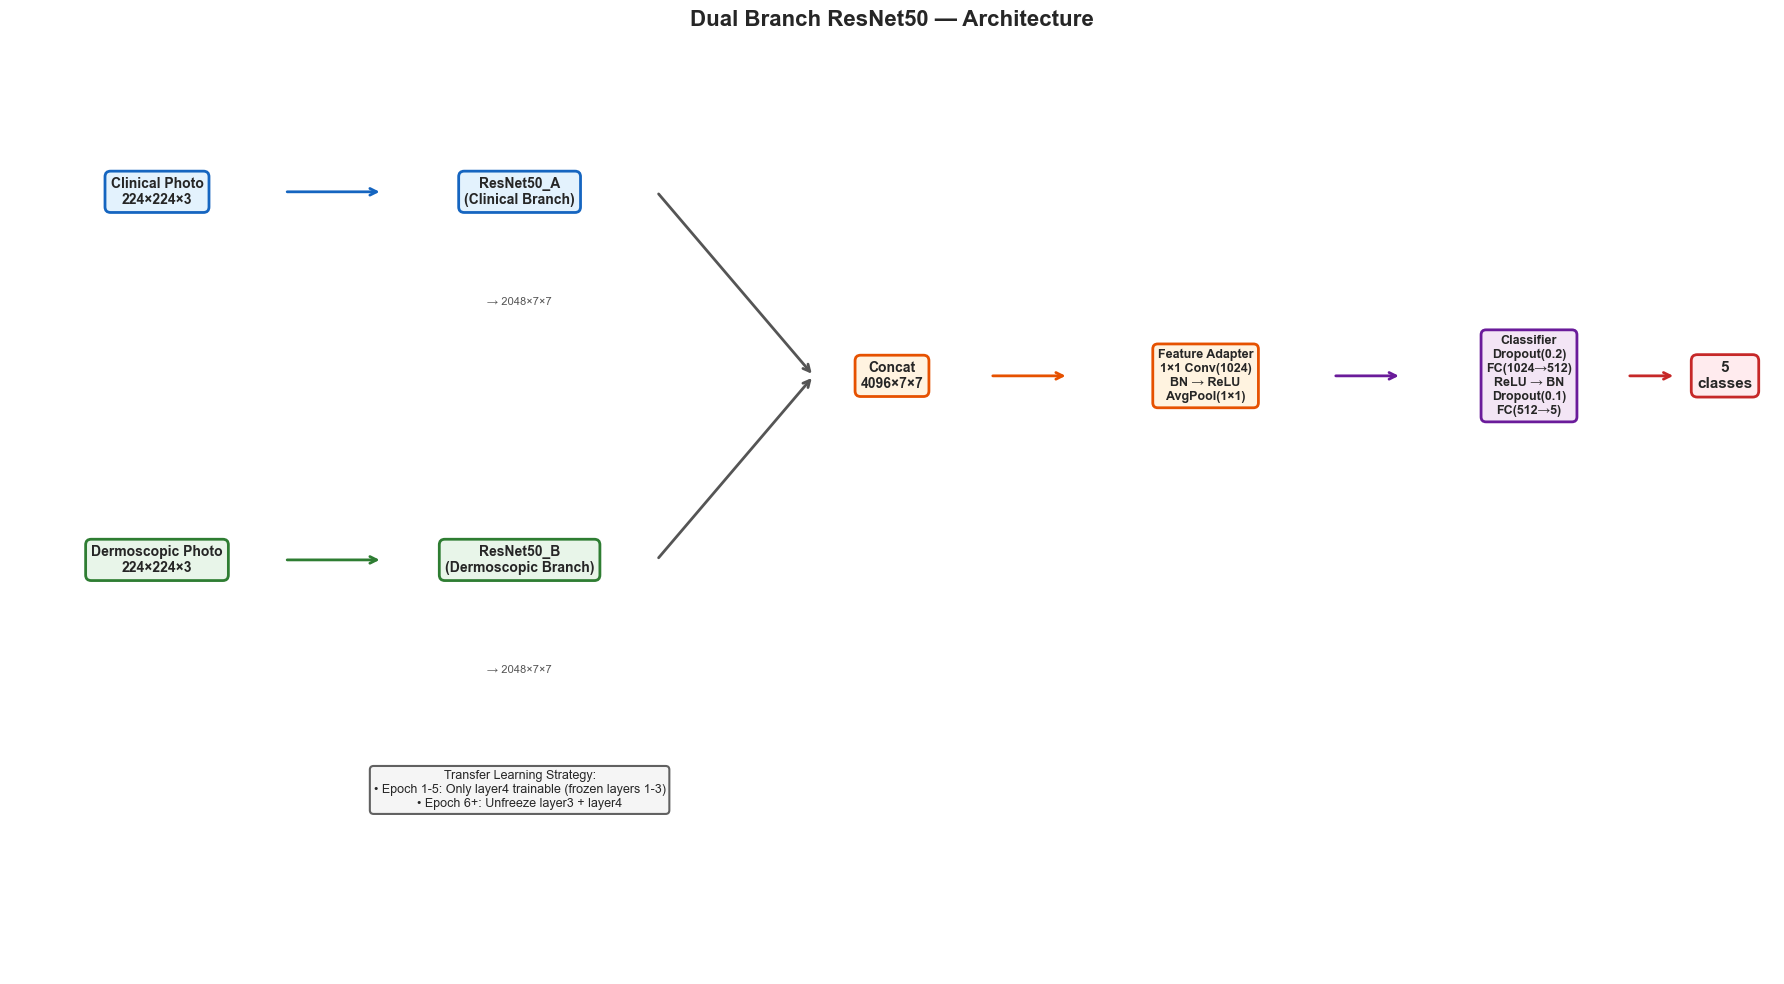

In [25]:
# Model architecture diagram
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis('off')

box = dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
box_green = dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)
box_orange = dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)
box_purple = dict(boxstyle='round,pad=0.4', facecolor='#F3E5F5', edgecolor='#6A1B9A', linewidth=2)
box_red = dict(boxstyle='round,pad=0.4', facecolor='#FFEBEE', edgecolor='#C62828', linewidth=2)
box_gray = dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', edgecolor='#616161', linewidth=1.5)

# Input images
ax.text(1.5, 8.5, 'Clinical Photo\n224×224×3', ha='center', va='center', fontsize=10, fontweight='bold', bbox=box)
ax.text(1.5, 4.5, 'Dermoscopic Photo\n224×224×3', ha='center', va='center', fontsize=10, fontweight='bold', bbox=box_green)

# Arrows from inputs to ResNets
ax.annotate('', xy=(3.8, 8.5), xytext=(2.8, 8.5), arrowprops=dict(arrowstyle='->', lw=2, color='#1565C0'))
ax.annotate('', xy=(3.8, 4.5), xytext=(2.8, 4.5), arrowprops=dict(arrowstyle='->', lw=2, color='#2E7D32'))

# ResNet50 branches
ax.text(5.2, 8.5, 'ResNet50_A\n(Clinical Branch)', ha='center', va='center', fontsize=10, fontweight='bold', bbox=box)
ax.text(5.2, 4.5, 'ResNet50_B\n(Dermoscopic Branch)', ha='center', va='center', fontsize=10, fontweight='bold', bbox=box_green)

# Feature map labels
ax.text(5.2, 7.3, '→ 2048×7×7', ha='center', va='center', fontsize=8, color='#555')
ax.text(5.2, 3.3, '→ 2048×7×7', ha='center', va='center', fontsize=8, color='#555')

# Arrows to concat
ax.annotate('', xy=(8.2, 6.5), xytext=(6.6, 8.5), arrowprops=dict(arrowstyle='->', lw=2, color='#555'))
ax.annotate('', xy=(8.2, 6.5), xytext=(6.6, 4.5), arrowprops=dict(arrowstyle='->', lw=2, color='#555'))

# Concatenate
ax.text(9.0, 6.5, 'Concat\n4096×7×7', ha='center', va='center', fontsize=10, fontweight='bold', bbox=box_orange)

# Arrow to adapter
ax.annotate('', xy=(10.8, 6.5), xytext=(10.0, 6.5), arrowprops=dict(arrowstyle='->', lw=2, color='#E65100'))

# Feature adapter
ax.text(12.2, 6.5, 'Feature Adapter\n1×1 Conv(1024)\nBN → ReLU\nAvgPool(1×1)', ha='center', va='center', fontsize=9, fontweight='bold', bbox=box_orange)

# Arrow to classifier
ax.annotate('', xy=(14.2, 6.5), xytext=(13.5, 6.5), arrowprops=dict(arrowstyle='->', lw=2, color='#6A1B9A'))

# Classifier
ax.text(15.5, 6.5, 'Classifier\nDropout(0.2)\nFC(1024→512)\nReLU → BN\nDropout(0.1)\nFC(512→5)', ha='center', va='center', fontsize=9, fontweight='bold', bbox=box_purple)

# Arrow to output
ax.annotate('', xy=(17.0, 6.5), xytext=(16.5, 6.5), arrowprops=dict(arrowstyle='->', lw=2, color='#C62828'))

# Output
ax.text(17.5, 6.5, '5\nclasses', ha='center', va='center', fontsize=11, fontweight='bold', bbox=box_red)

# Freeze/unfreeze annotation
ax.text(5.2, 2.0, 'Transfer Learning Strategy:\n• Epoch 1-5: Only layer4 trainable (frozen layers 1-3)\n• Epoch 6+: Unfreeze layer3 + layer4',
        ha='center', va='center', fontsize=9, bbox=box_gray)

ax.set_title('Dual Branch ResNet50 — Architecture', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [26]:
# Training (lr=0.001) — 5 runs
LR = 0.001
EPOCHS = 30
UNFREEZE_EPOCH = 5

criterion = nn.CrossEntropyLoss(weight=loss_weights)

run_histories = {}   # {run: history dict}
run_best = []        # [{run, best_val_loss, best_val_acc}]
best_overall_state = None
best_overall_loss = float('inf')

for run in range(1, 6):
    print(f"\n{'='*50}")
    print(f"  RUN {run}/5  (lr={LR})")
    print(f"{'='*50}")

    # Fresh model for each run
    model = DualBranchResNet(num_classes=len(class_names)).to(device)
    model._freeze_backbones()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_state = None
    start_time = time.time()

    for epoch in range(EPOCHS):
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_resnets()
            optimizer = optim.Adam(model.parameters(), lr=LR / 2)
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
            print(f"  Epoch {epoch+1}: Unfroze layer3+layer4, lr={LR/2}\n")

        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch_idx, (clinic_imgs, derm_imgs, labels_batch) in enumerate(train_loader):
            clinic_imgs = clinic_imgs.to(device)
            derm_imgs = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            optimizer.zero_grad()
            outputs = model(clinic_imgs, derm_imgs)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * clinic_imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels_batch).sum().item()
            total += clinic_imgs.size(0)

            if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
                print(f"\r  Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx+1}/{len(train_loader)} | "
                      f"Loss: {running_loss/total:.4f} | Acc: {correct/total:.4f}", end="", flush=True)

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Validate
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for clinic_imgs, derm_imgs, labels_batch in val_loader:
                clinic_imgs = clinic_imgs.to(device)
                derm_imgs = derm_imgs.to(device)
                labels_batch = labels_batch.to(device)
                outputs = model(clinic_imgs, derm_imgs)
                loss = criterion(outputs, labels_batch)
                running_loss += loss.item() * clinic_imgs.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(labels_batch).sum().item()
                total += clinic_imgs.size(0)

        val_loss = running_loss / total
        val_acc = correct / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step()

        print(f"\n  Epoch {epoch+1:2d} | Train {history['train_loss'][-1]:.4f}/{history['train_acc'][-1]:.4f} | "
              f"Val {val_loss:.4f}/{val_acc:.4f} | LR {optimizer.param_groups[0]['lr']:.1e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

    print(f"\nRun {run} done in {(time.time()-start_time)/60:.1f} min | best val loss: {best_val_loss:.4f}")
    model.load_state_dict(best_model_state)

    run_histories[run] = history
    run_best.append({'run': run, 'best_val_loss': best_val_loss, 'best_val_acc': max(history['val_acc'])})

    if best_val_loss < best_overall_loss:
        best_overall_loss = best_val_loss
        best_overall_state = copy.deepcopy(best_model_state)

# Load the best model across all runs for downstream evaluation
model.load_state_dict(best_overall_state)
print(f"\nLoaded best model overall (val loss: {best_overall_loss:.4f})")



  RUN 1/5  (lr=0.001)
  Epoch 1/30 | Batch 118/118 | Loss: 0.9031 | Acc: 0.4758
  Epoch  1 | Train 0.9031/0.4758 | Val 1.5527/0.2494 | LR 1.0e-03
  Epoch 2/30 | Batch 118/118 | Loss: 0.6127 | Acc: 0.5856
  Epoch  2 | Train 0.6127/0.5856 | Val 1.3982/0.3474 | LR 1.0e-03
  Epoch 3/30 | Batch 118/118 | Loss: 0.4646 | Acc: 0.6606
  Epoch  3 | Train 0.4646/0.6606 | Val 1.0639/0.5385 | LR 1.0e-03
  Epoch 4/30 | Batch 118/118 | Loss: 0.4521 | Acc: 0.6790
  Epoch  4 | Train 0.4521/0.6790 | Val 1.1782/0.4305 | LR 1.0e-03
  Epoch 5/30 | Batch 118/118 | Loss: 0.3865 | Acc: 0.7154
  Epoch  5 | Train 0.3865/0.7154 | Val 1.0791/0.5645 | LR 1.0e-03
  Epoch 6: Unfroze layer3+layer4, lr=0.0005

  Epoch 6/30 | Batch 118/118 | Loss: 0.4784 | Acc: 0.6689
  Epoch  6 | Train 0.4784/0.6689 | Val 1.1415/0.5546 | LR 5.0e-04
  Epoch 7/30 | Batch 118/118 | Loss: 0.4206 | Acc: 0.7080
  Epoch  7 | Train 0.4206/0.7080 | Val 1.1288/0.5174 | LR 5.0e-04
  Epoch 8/30 | Batch 118/118 | Loss: 0.3005 | Acc: 0.7601
  Epoc

Saved: dual_branch_best.pth, training_history.pkl


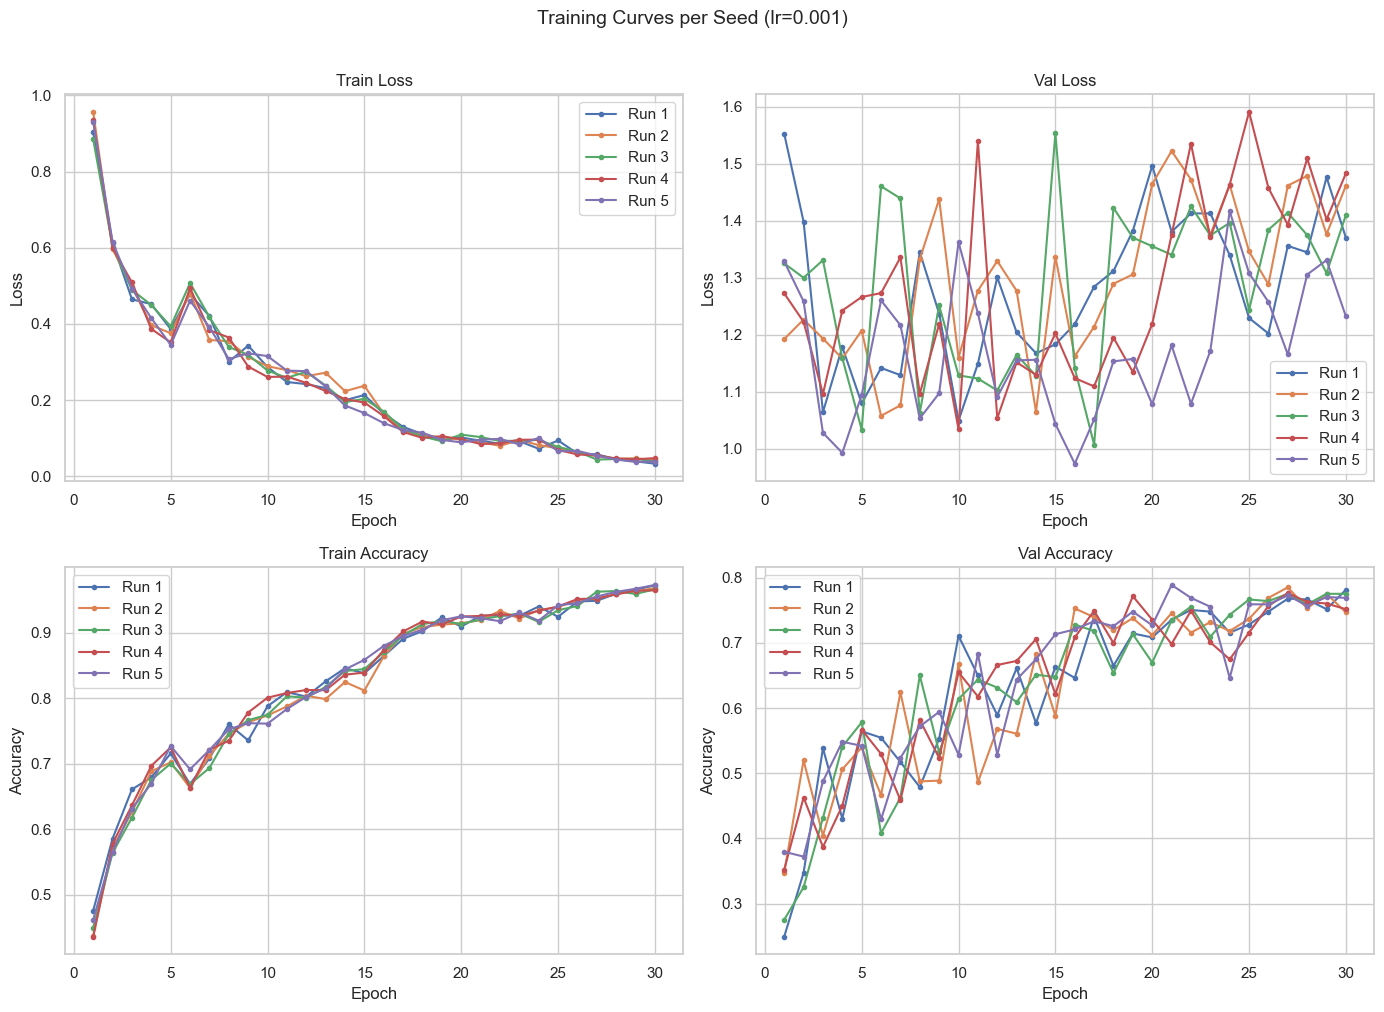

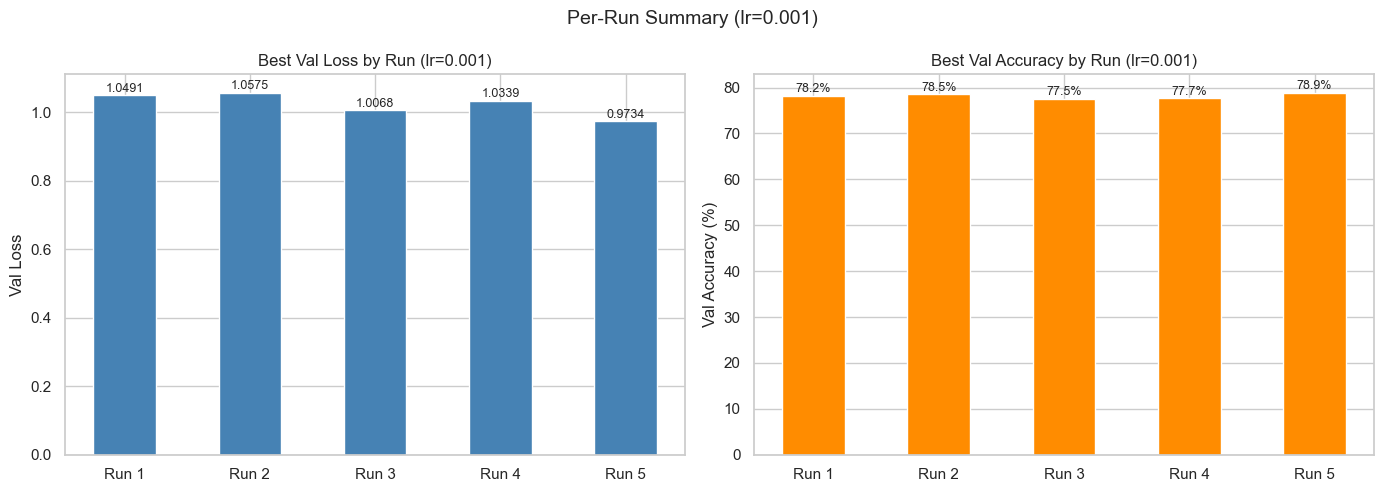

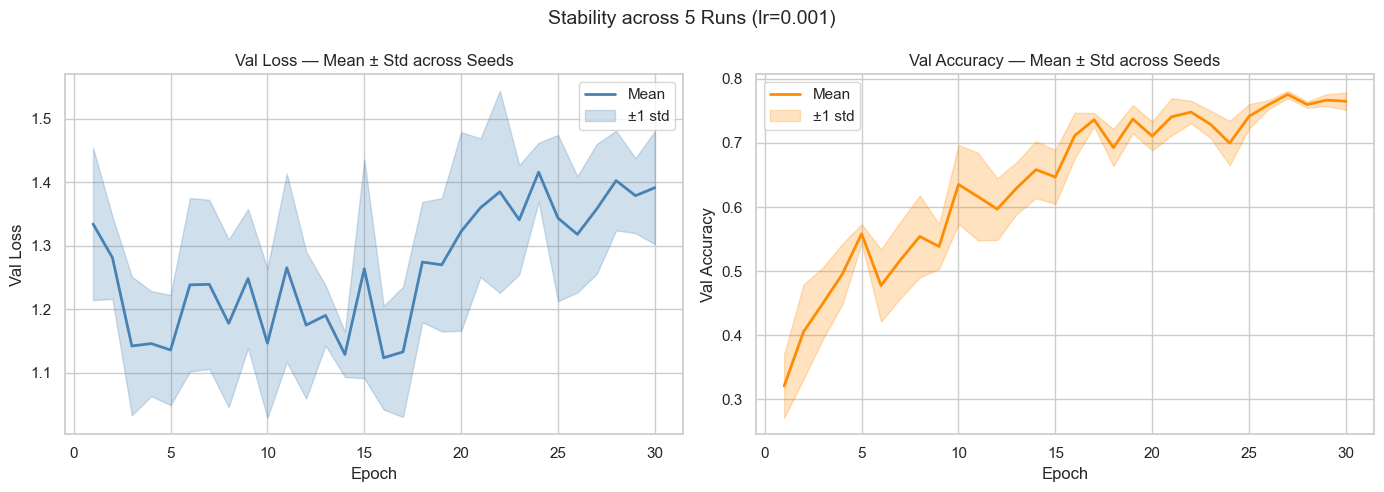

In [27]:
# Save best model + all run histories
import pickle

torch.save({
    'model_state_dict': best_overall_state,
    'class_names': class_names,
    'run_histories': run_histories,
    'run_best': run_best,
}, 'dual_branch_best.pth')
with open('training_history.pkl', 'wb') as f:
    pickle.dump(run_histories, f)
print("Saved: dual_branch_best.pth, training_history.pkl")

# ── Plot 1: Train loss / Val loss / Train acc / Val acc curves per seed ───────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax_tl, ax_vl, ax_ta, ax_va = axes.flatten()

for run, hist in run_histories.items():
    epochs_range = range(1, len(hist['train_loss']) + 1)
    ax_tl.plot(epochs_range, hist['train_loss'], marker='o', markersize=3, label=f'Run {run}')
    ax_vl.plot(epochs_range, hist['val_loss'],   marker='o', markersize=3, label=f'Run {run}')
    ax_ta.plot(epochs_range, hist['train_acc'],  marker='o', markersize=3, label=f'Run {run}')
    ax_va.plot(epochs_range, hist['val_acc'],    marker='o', markersize=3, label=f'Run {run}')

ax_tl.set_title('Train Loss'); ax_tl.set_xlabel('Epoch'); ax_tl.set_ylabel('Loss'); ax_tl.legend()
ax_vl.set_title('Val Loss');   ax_vl.set_xlabel('Epoch'); ax_vl.set_ylabel('Loss'); ax_vl.legend()
ax_ta.set_title('Train Accuracy'); ax_ta.set_xlabel('Epoch'); ax_ta.set_ylabel('Accuracy'); ax_ta.legend()
ax_va.set_title('Val Accuracy');   ax_va.set_xlabel('Epoch'); ax_va.set_ylabel('Accuracy'); ax_va.legend()

plt.suptitle('Training Curves per Seed (lr=0.001)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Plot 2: Best val loss & accuracy bar chart per seed ───────────────────────
runs_list  = [r['run'] for r in run_best]
best_losses = [r['best_val_loss'] for r in run_best]
best_accs   = [r['best_val_acc'] * 100 for r in run_best]
x = np.arange(len(runs_list))
bar_width = 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x, best_losses, bar_width, color='steelblue')
ax1.set_title('Best Val Loss by Run (lr=0.001)')
ax1.set_xticks(x); ax1.set_xticklabels([f'Run {r}' for r in runs_list])
ax1.set_ylabel('Val Loss')
for i, v in enumerate(best_losses):
    ax1.text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

ax2.bar(x, best_accs, bar_width, color='darkorange')
ax2.set_title('Best Val Accuracy by Run (lr=0.001)')
ax2.set_xticks(x); ax2.set_xticklabels([f'Run {r}' for r in runs_list])
ax2.set_ylabel('Val Accuracy (%)')
for i, v in enumerate(best_accs):
    ax2.text(i, v + 0.1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Per-Run Summary (lr=0.001)', fontsize=14)
plt.tight_layout()
plt.show()

# ── Plot 3: Mean ± std band across seeds ─────────────────────────────────────
max_epochs = max(len(h['val_loss']) for h in run_histories.values())

def pad(lst, length):
    return lst + [lst[-1]] * (length - len(lst))

tl = np.array([pad(h['train_loss'], max_epochs) for h in run_histories.values()])
vl = np.array([pad(h['val_loss'],   max_epochs) for h in run_histories.values()])
ta = np.array([pad(h['train_acc'],  max_epochs) for h in run_histories.values()])
va = np.array([pad(h['val_acc'],    max_epochs) for h in run_histories.values()])

ep = np.arange(1, max_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for arr, ax, label, color in [
    (vl, ax1, 'Val Loss',     'steelblue'),
    (va, ax2, 'Val Accuracy', 'darkorange'),
]:
    mean, std = arr.mean(0), arr.std(0)
    ax.plot(ep, mean, color=color, linewidth=2, label='Mean')
    ax.fill_between(ep, mean - std, mean + std, alpha=0.25, color=color, label='±1 std')
    ax.set_title(f'{label} — Mean ± Std across Seeds')
    ax.set_xlabel('Epoch'); ax.set_ylabel(label); ax.legend()

plt.suptitle('Stability across 5 Runs (lr=0.001)', fontsize=14)
plt.tight_layout()
plt.show()


In [28]:
# Evaluate on test set
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_score, recall_score, accuracy_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, average_precision_score, log_loss
)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for clinic_imgs, derm_imgs, labels_batch in test_loader:
        clinic_imgs, derm_imgs = clinic_imgs.to(device), derm_imgs.to(device)
        outputs = model(clinic_imgs, derm_imgs)
        probs = F.softmax(outputs, dim=1)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

y_true, y_pred, y_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

test_acc = accuracy_score(y_true, y_pred)
test_balanced_acc = balanced_accuracy_score(y_true, y_pred)
test_f1_macro = f1_score(y_true, y_pred, average='macro')
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
test_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
test_kappa = cohen_kappa_score(y_true, y_pred)
test_mcc = matthews_corrcoef(y_true, y_pred)
test_logloss = log_loss(y_true, y_probs)

print("=" * 50)
print("  TEST RESULTS")
print("=" * 50)
print(f"  Accuracy:          {test_acc:.4f}")
print(f"  Balanced Accuracy: {test_balanced_acc:.4f}")
print(f"  Precision (macro): {test_precision:.4f}")
print(f"  Recall (macro):    {test_recall:.4f}")
print(f"  F1 (macro):        {test_f1_macro:.4f}")
print(f"  F1 (weighted):     {test_f1_weighted:.4f}")
print(f"  Cohen's Kappa:     {test_kappa:.4f}")
print(f"  MCC:               {test_mcc:.4f}")
print(f"  Log Loss:          {test_logloss:.4f}")
print("=" * 50)
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

  TEST RESULTS
  Accuracy:          0.7605
  Balanced Accuracy: 0.7360
  Precision (macro): 0.6794
  Recall (macro):    0.7360
  F1 (macro):        0.6955
  F1 (weighted):     0.7716
  Cohen's Kappa:     0.6637
  MCC:               0.6701
  Log Loss:          0.8149

              precision    recall  f1-score   support

         BCC     0.9437    0.7865    0.8580       384
         MEL     0.6263    0.5849    0.6049       106
        MISC     0.5676    0.7241    0.6364        29
          NV     0.8020    0.7980    0.8000       198
          SK     0.4575    0.7865    0.5785        89

    accuracy                         0.7605       806
   macro avg     0.6794    0.7360    0.6955       806
weighted avg     0.8000    0.7605    0.7716       806



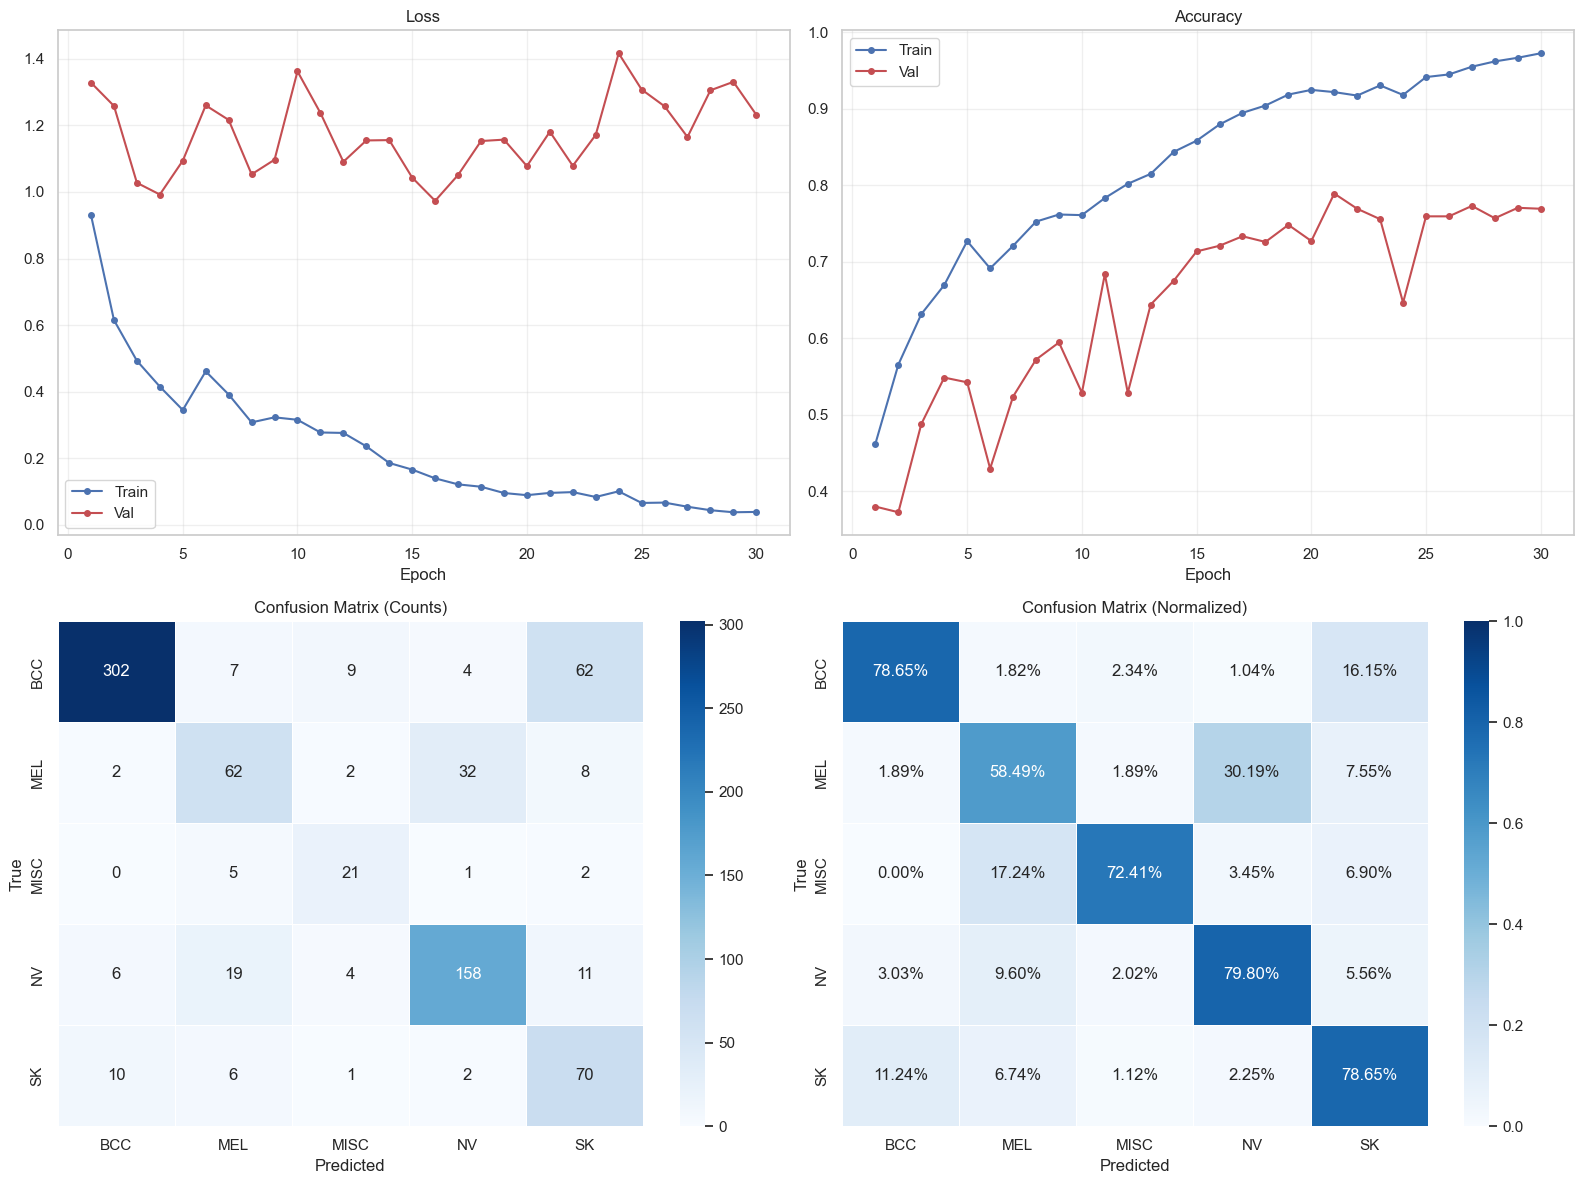

In [29]:
# Training curves + confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0,0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0,0].plot(epochs_range, history['val_loss'], 'r-o', label='Val', markersize=4)
axes[0,0].set_title('Loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(epochs_range, history['train_acc'], 'b-o', label='Train', markersize=4)
axes[0,1].plot(epochs_range, history['val_acc'], 'r-o', label='Val', markersize=4)
axes[0,1].set_title('Accuracy'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1,0], linewidths=0.5)
axes[1,0].set_title('Confusion Matrix (Counts)'); axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1,1], linewidths=0.5, vmin=0, vmax=1)
axes[1,1].set_title('Confusion Matrix (Normalized)'); axes[1,1].set_xlabel('Predicted'); axes[1,1].set_ylabel('True')

plt.tight_layout()
plt.show()

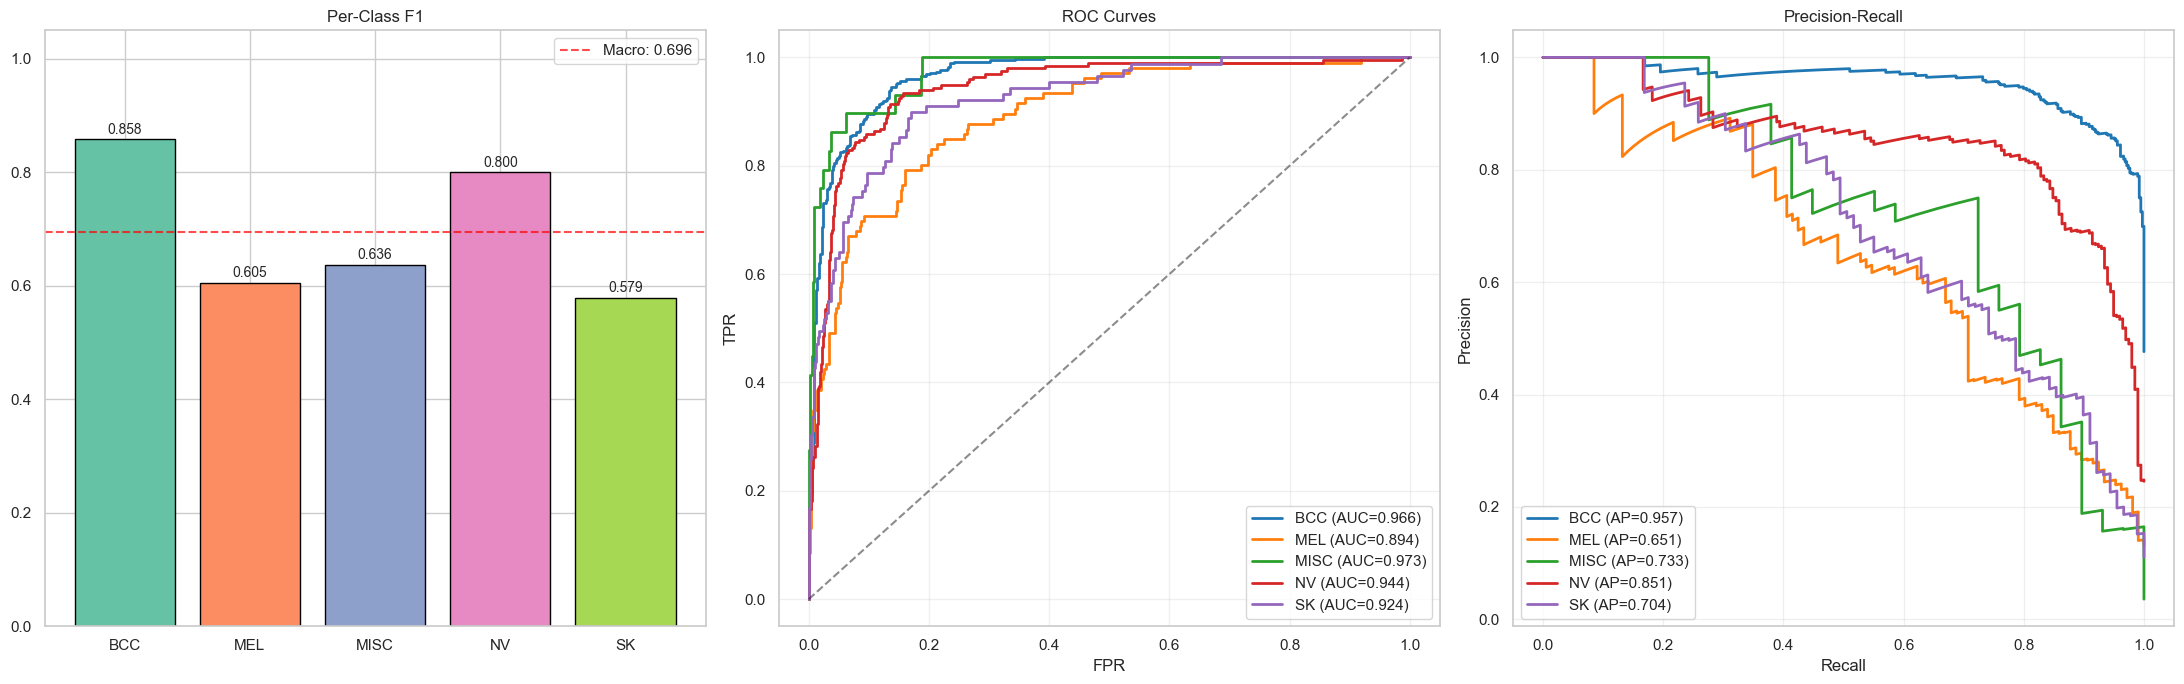

In [30]:
# F1 bars + ROC + Precision-Recall curves
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

# Per-class F1
per_class_f1 = f1_score(y_true, y_pred, average=None)
colors = sns.color_palette('Set2', len(class_names))
bars = ax1.bar(class_names, per_class_f1, color=colors, edgecolor='black')
ax1.set_title('Per-Class F1'); ax1.set_ylim(0, 1.05)
for bar, val in zip(bars, per_class_f1):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontsize=10)
ax1.axhline(y=test_f1_macro, color='red', linestyle='--', alpha=0.7, label=f'Macro: {test_f1_macro:.3f}')
ax1.legend()

# ROC curves
colors = sns.color_palette('tab10', len(class_names))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    ax2.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax2.set_title('ROC Curves'); ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR'); ax2.legend(loc='lower right'); ax2.grid(alpha=0.3)

# Precision-Recall curves
for i, (name, color) in enumerate(zip(class_names, colors)):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    ax3.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')
ax3.set_title('Precision-Recall'); ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision'); ax3.legend(loc='lower left'); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

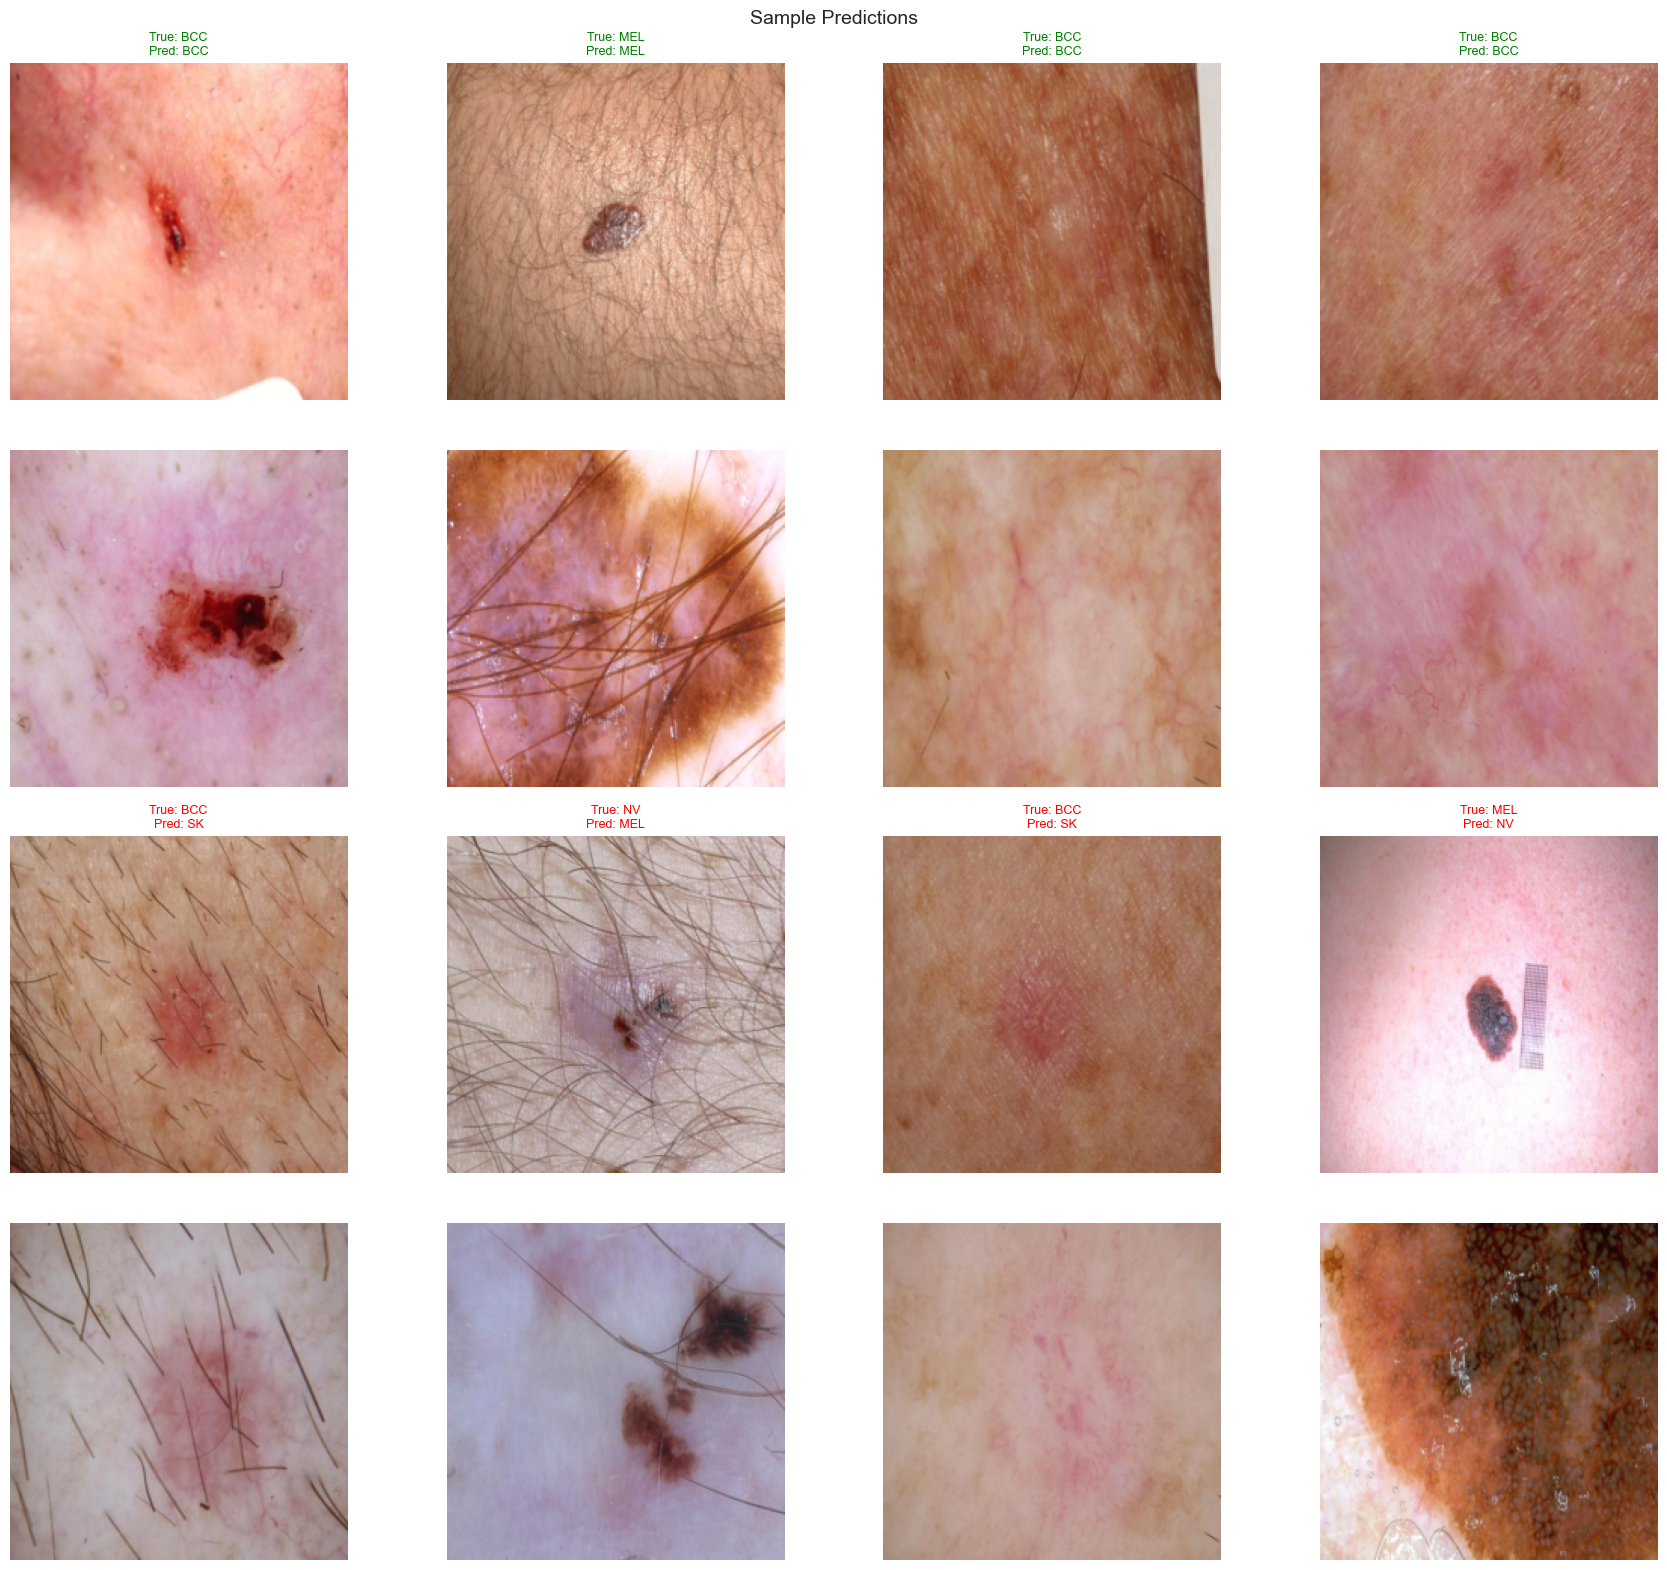

In [31]:
# Sample predictions — clinical + dermoscopic pairs
inv_normalize = transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])

correct_idx = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for j in range(min(4, len(correct_idx))):
    idx = correct_idx[j]
    c, d, _ = test_ds[idx]
    axes[0, j].imshow(inv_normalize(c).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, j].set_title(f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}', fontsize=9, color='green')
    axes[0, j].axis('off')
    axes[1, j].imshow(inv_normalize(d).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, j].axis('off')

for j in range(min(4, len(incorrect_idx))):
    idx = incorrect_idx[j]
    c, d, _ = test_ds[idx]
    axes[2, j].imshow(inv_normalize(c).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[2, j].set_title(f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}', fontsize=9, color='red')
    axes[2, j].axis('off')
    axes[3, j].imshow(inv_normalize(d).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[3, j].axis('off')

axes[0,0].set_ylabel('Correct\n(Clinical)', fontsize=11, color='green')
axes[1,0].set_ylabel('Correct\n(Derm)', fontsize=11, color='green')
axes[2,0].set_ylabel('Wrong\n(Clinical)', fontsize=11, color='red')
axes[3,0].set_ylabel('Wrong\n(Derm)', fontsize=11, color='red')
plt.suptitle('Sample Predictions', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Per-class summary table + save results
per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
per_class_f1 = f1_score(y_true, y_pred, average=None)
per_class_auc, per_class_ap, per_class_spec = [], [], []

y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    per_class_auc.append(auc(fpr, tpr))
    per_class_ap.append(average_precision_score(y_true_bin[:, i], y_probs[:, i]))
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]
    per_class_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

results_df = pd.DataFrame({
    'Class': class_names, 'Precision': per_class_precision.round(4),
    'Recall': per_class_recall.round(4), 'Specificity': np.array(per_class_spec).round(4),
    'F1': per_class_f1.round(4), 'AUC': np.array(per_class_auc).round(4),
    'AP': np.array(per_class_ap).round(4), 'Support': np.bincount(y_true),
})
macro = pd.DataFrame({
    'Class': ['Macro Avg'], 'Precision': [per_class_precision.mean().round(4)],
    'Recall': [per_class_recall.mean().round(4)], 'Specificity': [np.mean(per_class_spec).round(4)],
    'F1': [per_class_f1.mean().round(4)], 'AUC': [np.mean(per_class_auc).round(4)],
    'AP': [np.mean(per_class_ap).round(4)], 'Support': [len(y_true)],
})
results_df = pd.concat([results_df, macro], ignore_index=True)
print("Per-Class Summary:")
display(results_df)

# Save everything
import pickle
eval_results = {
    'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs, 'class_names': class_names,
    'metrics': {'accuracy': test_acc, 'balanced_accuracy': test_balanced_acc,
                'precision_macro': test_precision, 'recall_macro': test_recall,
                'f1_macro': test_f1_macro, 'f1_weighted': test_f1_weighted,
                'cohen_kappa': test_kappa, 'matthews_cc': test_mcc, 'log_loss': test_logloss},
    'confusion_matrix': cm, 'confusion_matrix_normalized': cm_norm,
}
with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump(eval_results, f)
results_df.to_csv('per_class_results.csv', index=False)
print("\nSaved: evaluation_results.pkl, per_class_results.csv")

Per-Class Summary:


,Class,Precision,Recall,Specificity,F1,AUC,AP,Support
0,BCC,0.9438,0.7865,0.9573,0.8580,0.9663,0.9569,384
1,MEL,0.6263,0.5849,0.9471,0.6049,0.8940,0.6506,106
2,MISC,0.5676,0.7241,0.9794,0.6364,0.9735,0.7327,29
3,NV,0.8020,0.7980,0.9359,0.8000,0.9444,0.8513,198
4,SK,0.4575,0.7865,0.8842,0.5785,0.9235,0.7044,89
5,Macro Avg,0.6794,0.7360,0.9408,0.6955,0.9403,0.7792,806



Saved: evaluation_results.pkl, per_class_results.csv


## Conclusion

**Dual Branch ResNet50** trained on Derm7pt (1,011 samples, 5 classes: MEL/NV/BCC/SK/MISC).

- **Branch A** (clinical photo) + **Branch B** (dermoscopic photo) → concatenated features → 1×1 conv compression → classifier
- Mirrors real dermatology: naked-eye exam + dermoscope for dual perspective
- Class imbalance handled via weighted loss + weighted sampling + stratified splits
- Transfer learning with gradual unfreezing + early stopping

**Limitations**: Small dataset (1,011 samples), class imbalance, single institution.

**Future work**: K-fold cross-validation, Grad-CAM visualization, attention-based fusion.

---

## Ablation Study

Comparing 4 configurations to isolate contributions of dataset size and dual-branch fusion:

| Config | Architecture | Dataset | Purpose |
|--------|-------------|---------|---------|
| **A** | Dual-branch ResNet50 | Derm7pt only (1,011) | Baseline — no MILK10k |
| **B** | Dual-branch ResNet50 | Derm7pt + MILK10k (5,372) | Main model — already trained above |
| **C** | Single-branch ResNet50 (derm only) | Derm7pt + MILK10k | Ablate clinical branch |
| **D** | Single-branch ResNet50 (clinical only) | Derm7pt + MILK10k | Ablate derm branch |

**A vs B**: value of MILK10k  
**B vs C/D**: value of dual-branch fusion vs single modality

Configs A, C, D: 3 runs × 20 epochs. Config B results loaded from main training above.

In [33]:
# ── Ablation helpers ────────────────────────────────────────────────────────

class SingleBranchResNet(nn.Module):
    """Single ResNet50 branch for single-modality ablation."""
    def __init__(self, num_classes, dropout_rate=0.2):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(512, num_classes)
        )

    def _freeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = False
        for p in self.features[7].parameters(): p.requires_grad = True  # layer4

    def unfreeze(self):
        for p in self.features[6].parameters(): p.requires_grad = True  # layer3

    def forward(self, x):
        feat = self.pool(self.features(x)).view(x.size(0), -1)
        return self.classifier(feat)


class SingleModalityDataset(Dataset):
    """Returns (img, label) using only one image modality per sample."""
    def __init__(self, dataframe, modality='derm', transform=None):
        assert modality in ('derm', 'clinic')
        self.df = dataframe.reset_index(drop=True)
        self.col = 'derm_path' if modality == 'derm' else 'clinic_path'
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[self.col]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(row['label'], dtype=torch.long)


def make_loaders_single(df_tr, df_va, df_te, modality, batch_size=32):
    tr_labels = df_tr['label'].values.astype(int)
    cc = np.bincount(tr_labels)
    sw = (1.0 / cc)[tr_labels]
    lw = torch.tensor([len(tr_labels) / (len(class_names) * c) for c in cc],
                      dtype=torch.float32).to(device)
    samp = WeightedRandomSampler(sw, len(tr_labels), replacement=True)
    tr = DataLoader(SingleModalityDataset(df_tr, modality, train_transform),
                    batch_size=batch_size, sampler=samp, num_workers=0)
    va = DataLoader(SingleModalityDataset(df_va, modality, val_transform),
                    batch_size=batch_size, shuffle=False, num_workers=0)
    te = DataLoader(SingleModalityDataset(df_te, modality, val_transform),
                    batch_size=batch_size, shuffle=False, num_workers=0)
    return tr, va, te, lw


def make_loaders_dual(df_tr, df_va, df_te, batch_size=32):
    tr_labels = df_tr['label'].values.astype(int)
    cc = np.bincount(tr_labels)
    sw = (1.0 / cc)[tr_labels]
    lw = torch.tensor([len(tr_labels) / (len(class_names) * c) for c in cc],
                      dtype=torch.float32).to(device)
    samp = WeightedRandomSampler(sw, len(tr_labels), replacement=True)
    tr = DataLoader(SkinLesionDualDataset(df_tr, train_transform),
                    batch_size=batch_size, sampler=samp, num_workers=0)
    va = DataLoader(SkinLesionDualDataset(df_va, val_transform),
                    batch_size=batch_size, shuffle=False, num_workers=0)
    te = DataLoader(SkinLesionDualDataset(df_te, val_transform),
                    batch_size=batch_size, shuffle=False, num_workers=0)
    return tr, va, te, lw


def train_config(model_fn, tr_loader, va_loader, loss_w,
                 is_dual=True, n_runs=3, epochs=20, lr=0.001, unfreeze_ep=5):
    """Train n_runs times; return best state + metrics dict."""
    best_state, best_loss = None, float('inf')
    for run in range(1, n_runs + 1):
        m = model_fn().to(device)
        if is_dual: m._freeze_backbones()
        else:       m._freeze_backbone()
        opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()), lr=lr)
        sched = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)
        crit = nn.CrossEntropyLoss(weight=loss_w)
        bvl, bstate = float('inf'), None

        for ep in range(epochs):
            if ep == unfreeze_ep:
                if is_dual: m.unfreeze_resnets()
                else:       m.unfreeze()
                opt = optim.Adam(m.parameters(), lr=lr / 2)
                sched = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.5)

            m.train()
            for batch in tr_loader:
                if is_dual:
                    ci, di, lb = batch
                    ci, di, lb = ci.to(device), di.to(device), lb.to(device)
                    out = m(ci, di)
                else:
                    img, lb = batch
                    img, lb = img.to(device), lb.to(device)
                    out = m(img)
                opt.zero_grad(); loss = crit(out, lb); loss.backward(); opt.step()

            m.eval(); rl, tot = 0.0, 0
            with torch.no_grad():
                for batch in va_loader:
                    if is_dual:
                        ci, di, lb = batch; ci, di, lb = ci.to(device), di.to(device), lb.to(device)
                        out = m(ci, di)
                    else:
                        img, lb = batch; img, lb = img.to(device), lb.to(device)
                        out = m(img)
                    rl += nn.CrossEntropyLoss(weight=loss_w)(out, lb).item() * lb.size(0); tot += lb.size(0)
            vl = rl / tot
            if vl < bvl: bvl = vl; bstate = copy.deepcopy(m.state_dict())
            sched.step()
            print(f"  Run {run}/{n_runs} | Ep {ep+1}/{epochs} | val_loss {vl:.4f}", end='\r')

        if bvl < best_loss: best_loss = bvl; best_state = bstate
        print(f"  Run {run}/{n_runs} done — best val loss: {bvl:.4f}          ")

    return best_state, best_loss


def evaluate_loader(model_fn, state, te_loader, is_dual=True):
    """Load state into fresh model, run test set, return (y_true, y_pred, y_probs)."""
    m = model_fn().to(device)
    m.load_state_dict(state); m.eval()
    yt, yp, ypr = [], [], []
    with torch.no_grad():
        for batch in te_loader:
            if is_dual:
                ci, di, lb = batch; ci, di = ci.to(device), di.to(device)
                out = m(ci, di)
            else:
                img, lb = batch; img = img.to(device)
                out = m(img)
            yp.extend(out.argmax(1).cpu().numpy())
            yt.extend(lb.numpy())
            ypr.extend(F.softmax(out, dim=1).cpu().numpy())
    return np.array(yt), np.array(yp), np.array(ypr)


def quick_metrics(yt, yp):
    return {
        'acc':      accuracy_score(yt, yp),
        'bal_acc':  balanced_accuracy_score(yt, yp),
        'f1_macro': f1_score(yt, yp, average='macro', zero_division=0),
        'kappa':    cohen_kappa_score(yt, yp),
        'mcc':      matthews_corrcoef(yt, yp),
    }

print("Ablation helpers defined.")

Ablation helpers defined.


In [34]:
# ── Config A: Dual-branch, Derm7pt only ─────────────────────────────────────
print("=" * 55)
print("  CONFIG A — Dual-branch | Derm7pt only")
print("=" * 55)

# Rebuild Derm7pt-only split (same label space, same 70/15/15)
derm7_only = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_only['label'] = derm7_only['diagnosis_group'].map(label_map)
derm7_only = derm7_only.dropna(subset=['label']).reset_index(drop=True)

d7_labels = derm7_only['label'].values.astype(int)
d7_idx = np.arange(len(derm7_only))
d7_tr, d7_tmp = train_test_split(d7_idx, test_size=0.3, stratify=d7_labels, random_state=42)
d7_va, d7_te  = train_test_split(d7_tmp, test_size=0.5, stratify=d7_labels[d7_tmp], random_state=42)

a_tr, a_va, a_te, a_lw = make_loaders_dual(
    derm7_only.iloc[d7_tr], derm7_only.iloc[d7_va], derm7_only.iloc[d7_te])
print(f"Derm7pt split — Train: {len(d7_tr)} | Val: {len(d7_va)} | Test: {len(d7_te)}")

a_state, a_best_loss = train_config(
    lambda: DualBranchResNet(num_classes=len(class_names)),
    a_tr, a_va, a_lw, is_dual=True, n_runs=3, epochs=20)

a_yt, a_yp, a_ypr = evaluate_loader(
    lambda: DualBranchResNet(num_classes=len(class_names)), a_state, a_te, is_dual=True)
a_metrics = quick_metrics(a_yt, a_yp)
print(f"\nConfig A test — Acc: {a_metrics['acc']:.4f} | F1: {a_metrics['f1_macro']:.4f} | Kappa: {a_metrics['kappa']:.4f}")
torch.save({'model_state_dict': a_state, 'metrics': a_metrics}, 'ablation_A_derm7pt_dual.pth')

  CONFIG A — Dual-branch | Derm7pt only
Derm7pt split — Train: 707 | Val: 152 | Test: 152
  Run 1/3 done — best val loss: 0.9090          
  Run 2/3 done — best val loss: 0.8267          
  Run 3/3 done — best val loss: 0.7855          

Config A test — Acc: 0.7303 | F1: 0.6408 | Kappa: 0.5778


In [35]:
# ── Config C: Single-branch derm, combined ──────────────────────────────────
print("=" * 55)
print("  CONFIG C — Single-branch (derm only) | Combined")
print("=" * 55)

c_tr, c_va, c_te, c_lw = make_loaders_single(
    df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx], modality='derm')

c_state, c_best_loss = train_config(
    lambda: SingleBranchResNet(num_classes=len(class_names)),
    c_tr, c_va, c_lw, is_dual=False, n_runs=3, epochs=20)

c_yt, c_yp, c_ypr = evaluate_loader(
    lambda: SingleBranchResNet(num_classes=len(class_names)), c_state, c_te, is_dual=False)
c_metrics = quick_metrics(c_yt, c_yp)
print(f"\nConfig C test — Acc: {c_metrics['acc']:.4f} | F1: {c_metrics['f1_macro']:.4f} | Kappa: {c_metrics['kappa']:.4f}")
torch.save({'model_state_dict': c_state, 'metrics': c_metrics}, 'ablation_C_derm_single.pth')

# ── Config D: Single-branch clinical, combined ───────────────────────────────
print()
print("=" * 55)
print("  CONFIG D — Single-branch (clinical only) | Combined")
print("=" * 55)

d_tr, d_va, d_te, d_lw = make_loaders_single(
    df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx], modality='clinic')

d_state, d_best_loss = train_config(
    lambda: SingleBranchResNet(num_classes=len(class_names)),
    d_tr, d_va, d_lw, is_dual=False, n_runs=3, epochs=20)

d_yt, d_yp, d_ypr = evaluate_loader(
    lambda: SingleBranchResNet(num_classes=len(class_names)), d_state, d_te, is_dual=False)
d_metrics = quick_metrics(d_yt, d_yp)
print(f"\nConfig D test — Acc: {d_metrics['acc']:.4f} | F1: {d_metrics['f1_macro']:.4f} | Kappa: {d_metrics['kappa']:.4f}")
torch.save({'model_state_dict': d_state, 'metrics': d_metrics}, 'ablation_D_clinic_single.pth')

  CONFIG C — Single-branch (derm only) | Combined
  Run 1/3 done — best val loss: 1.0685          
  Run 2/3 done — best val loss: 1.0727          
  Run 3/3 done — best val loss: 1.0503          

Config C test — Acc: 0.6501 | F1: 0.5650 | Kappa: 0.5296

  CONFIG D — Single-branch (clinical only) | Combined
  Run 1/3 done — best val loss: 1.2537          
  Run 2/3 done — best val loss: 1.2130          
  Run 3/3 done — best val loss: 1.2318          

Config D test — Acc: 0.4603 | F1: 0.4472 | Kappa: 0.3375



Ablation Study Summary


,Config,acc,bal_acc,f1_macro,kappa,mcc
0,A: Dual / Derm7pt only,0.7303,0.6842,0.6408,0.5778,0.5861
1,B: Dual / Combined,0.7605,0.7360,0.6955,0.6637,0.6701
2,C: Single-derm / Combined,0.6501,0.6394,0.5650,0.5296,0.5434
3,D: Single-clinic / Combined,0.4603,0.5715,0.4472,0.3375,0.3831


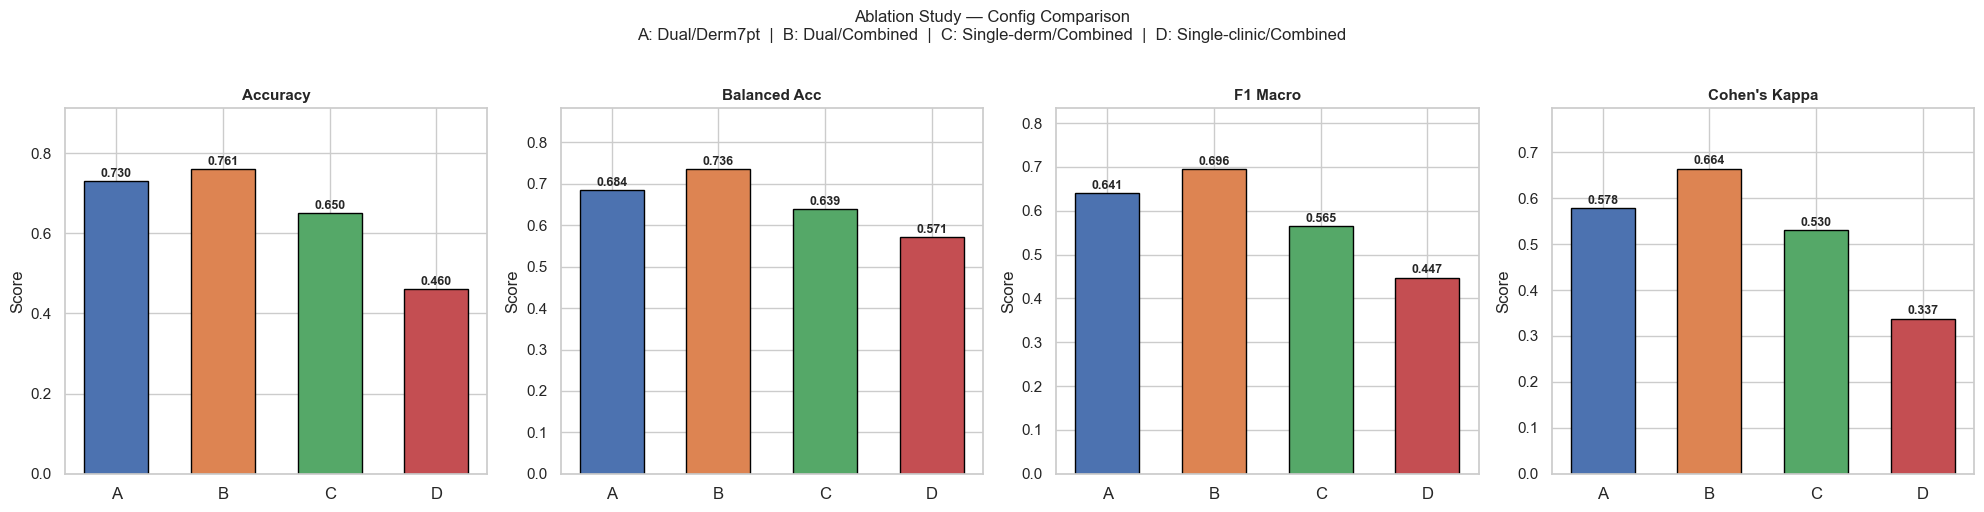

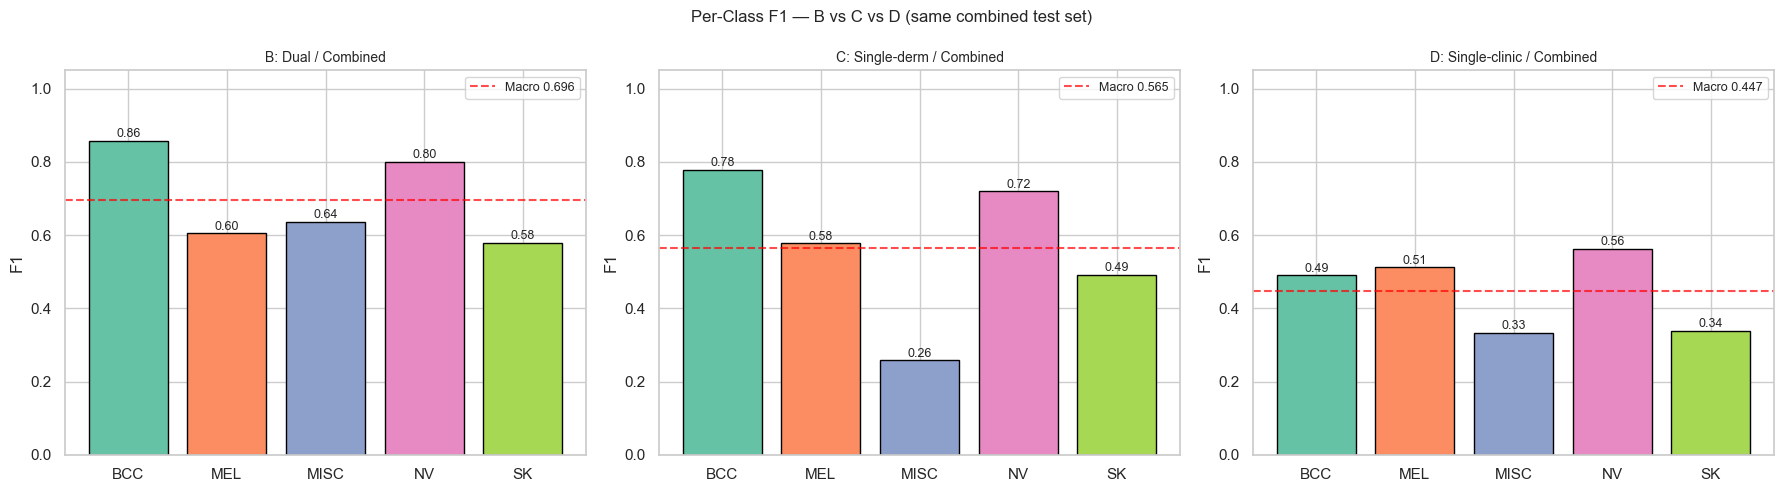

Saved: ablation_results.csv


In [36]:
# ── Ablation comparison table + plots ───────────────────────────────────────
b_metrics = {
    'acc':      test_acc,
    'bal_acc':  test_balanced_acc,
    'f1_macro': test_f1_macro,
    'kappa':    test_kappa,
    'mcc':      test_mcc,
}

configs = {
    'A: Dual / Derm7pt only':    a_metrics,
    'B: Dual / Combined':         b_metrics,
    'C: Single-derm / Combined':  c_metrics,
    'D: Single-clinic / Combined': d_metrics,
}

summary = pd.DataFrame(configs).T.reset_index().rename(columns={'index': 'Config'})
summary[['acc', 'bal_acc', 'f1_macro', 'kappa', 'mcc']] = (
    summary[['acc', 'bal_acc', 'f1_macro', 'kappa', 'mcc']].astype(float).round(4))
print("\nAblation Study Summary")
print("=" * 70)
display(summary)
summary.to_csv('ablation_results.csv', index=False)

# Bar chart comparison
metrics_to_plot = ['acc', 'bal_acc', 'f1_macro', 'kappa']
labels_plot = ['Accuracy', 'Balanced Acc', 'F1 Macro', "Cohen's Kappa"]
config_labels = list(configs.keys())
colors_cfg = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric, label in zip(axes, metrics_to_plot, labels_plot):
    vals = [configs[c][metric] for c in config_labels]
    bars = ax.bar(range(len(config_labels)), vals, color=colors_cfg, edgecolor='black', width=0.6)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(config_labels)))
    ax.set_xticklabels(['A', 'B', 'C', 'D'], fontsize=12)
    ax.set_ylim(0, min(1.0, max(vals) * 1.2))
    ax.set_ylabel('Score')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Ablation Study — Config Comparison\n'
             'A: Dual/Derm7pt  |  B: Dual/Combined  |  C: Single-derm/Combined  |  D: Single-clinic/Combined',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Per-class F1 comparison for B, C, D (same test set)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, yt, yp) in zip(axes, [
    ('B: Dual / Combined', y_true, y_pred),
    ('C: Single-derm / Combined', c_yt, c_yp),
    ('D: Single-clinic / Combined', d_yt, d_yp),
]):
    pcf1 = f1_score(yt, yp, average=None, zero_division=0)
    bars = ax.bar(class_names, pcf1, color=sns.color_palette('Set2', len(class_names)), edgecolor='black')
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1')
    for bar, v in zip(bars, pcf1):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', fontsize=9)
    ax.axhline(pcf1.mean(), color='red', linestyle='--', alpha=0.7,
               label=f'Macro {pcf1.mean():.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Per-Class F1 — B vs C vs D (same combined test set)', fontsize=12)
plt.tight_layout()
plt.show()

print("Saved: ablation_results.csv")

In [37]:
# ── Save all models ─────────────────────────────────────────────────────────
import pickle
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Consolidated checkpoint — all 4 configs in one file
all_models = {
    'timestamp': timestamp,
    'class_names': class_names,
    'label_map': label_map,
    'configs': {
        'A_dual_derm7pt': {
            'description': 'Dual-branch ResNet50, Derm7pt only (1,011 samples), 3 runs x 20 epochs',
            'model_state_dict': a_state,
            'metrics': a_metrics,
        },
        'B_dual_combined': {
            'description': 'Dual-branch ResNet50, Derm7pt + MILK10k (5,372 samples), 5 runs x 30 epochs',
            'model_state_dict': best_overall_state,
            'metrics': {
                'acc': test_acc, 'bal_acc': test_balanced_acc,
                'f1_macro': test_f1_macro, 'kappa': test_kappa, 'mcc': test_mcc,
            },
            'run_histories': run_histories,
            'run_best': run_best,
        },
        'C_single_derm_combined': {
            'description': 'Single-branch ResNet50 (derm only), Derm7pt + MILK10k, 3 runs x 20 epochs',
            'model_state_dict': c_state,
            'metrics': c_metrics,
        },
        'D_single_clinic_combined': {
            'description': 'Single-branch ResNet50 (clinical only), Derm7pt + MILK10k, 3 runs x 20 epochs',
            'model_state_dict': d_state,
            'metrics': d_metrics,
        },
    },
    'ablation_summary': summary.to_dict(orient='records'),
}

consolidated_path = f'all_models_{timestamp}.pth'
torch.save(all_models, consolidated_path)

# Also save full eval results for Config B
with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump({
        'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs,
        'class_names': class_names,
        'metrics': all_models['configs']['B_dual_combined']['metrics'],
        'confusion_matrix': cm, 'confusion_matrix_normalized': cm_norm,
    }, f)

print("=" * 55)
print("  ALL MODELS SAVED")
print("=" * 55)
saved_files = [
    (consolidated_path,              'Consolidated checkpoint — all 4 configs'),
    ('dual_branch_best.pth',         'Config B — dual branch + combined (main model)'),
    ('ablation_A_derm7pt_dual.pth',  'Config A — dual branch + Derm7pt only'),
    ('ablation_C_derm_single.pth',   'Config C — single branch derm + combined'),
    ('ablation_D_clinic_single.pth', 'Config D — single branch clinical + combined'),
    ('training_history.pkl',         'Config B training curves (5 runs)'),
    ('evaluation_results.pkl',       'Config B full eval (y_true, y_pred, y_probs, metrics)'),
    ('per_class_results.csv',        'Config B per-class metrics table'),
    ('ablation_results.csv',         'Ablation summary table (all 4 configs)'),
]

import os
for fname, desc in saved_files:
    size = os.path.getsize(fname) / 1e6 if os.path.exists(fname) else 0
    status = f'{size:.1f} MB' if size > 0 else 'MISSING'
    print(f'  [{status:>8}]  {fname}')
    print(f'             {desc}')


  ALL MODELS SAVED
  [612.4 MB]  all_models_20260503_221659.pth
             Consolidated checkpoint — all 4 configs
  [207.6 MB]  dual_branch_best.pth
             Config B — dual branch + combined (main model)
  [207.6 MB]  ablation_A_derm7pt_dual.pth
             Config A — dual branch + Derm7pt only
  [ 98.6 MB]  ablation_C_derm_single.pth
             Config C — single branch derm + combined
  [ 98.6 MB]  ablation_D_clinic_single.pth
             Config D — single branch clinical + combined
  [  0.0 MB]  training_history.pkl
             Config B training curves (5 runs)
  [  0.0 MB]  evaluation_results.pkl
             Config B full eval (y_true, y_pred, y_probs, metrics)
  [  0.0 MB]  per_class_results.csv
             Config B per-class metrics table
  [  0.0 MB]  ablation_results.csv
             Ablation summary table (all 4 configs)
